<h1 style="color:red;">Dialect Identification</h1>

<h1 style="color:red;">Importing Libraries</h1>

In [11]:
import pandas as pd
import os
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm
from sklearn.model_selection import GridSearchCV
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from torch.nn.utils.rnn import pad_sequence
import numpy as np
from itertools import chain
from collections import Counter
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import random
import warnings

warnings.filterwarnings('ignore')

<h1 style="color:red;">Loading & Exploring Dataset</h1>

In [12]:
# Specify the folder path containing the files
folder_path = "MADAR.Parallel-Corpora-Public-Version1.1-25MAR2021/MADAR_Corpus"

# List of specific files to skip (if any, otherwise leave it empty)
skip_files = ['MADAR.corpus.French.index.tsv', 'MADAR.corpus.English.index.tsv']

# Initialize empty DataFrames for test, dev, and train
test_df = pd.DataFrame()
dev_df = pd.DataFrame()
train_df = pd.DataFrame()

# Loop through all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".tsv") and file_name not in skip_files:  # Skip the specific files
        file_path = os.path.join(folder_path, file_name)  # Get full path
        # Read only the relevant columns ('lang', 'sent', 'split')
        temp_df = pd.read_csv(file_path, sep="\t", usecols=['lang', 'sent', 'split'])
        # Filter rows where the 'split' column contains 'corpus-26'
        temp_df = temp_df[temp_df['split'].str.contains('corpus-26', na=False)]
        # Drop the 'split' column as it's no longer needed
        temp_df = temp_df.drop(columns=['split'])
        # Shuffle the rows to ensure random distribution
        temp_df = temp_df.sample(frac=1, random_state=42).reset_index(drop=True)
        
        # Calculate the number of rows for each split
        total_rows = len(temp_df)
        train_count = int(total_rows * 0.8)
        dev_count = int(total_rows * 0.1)
        test_count = total_rows - train_count - dev_count
        
        # Split the data
        train_df = pd.concat([train_df, temp_df[:train_count]], ignore_index=True)
        dev_df = pd.concat([dev_df, temp_df[train_count:train_count + dev_count]], ignore_index=True)
        test_df = pd.concat([test_df, temp_df[train_count + dev_count:]], ignore_index=True)

# Shuffle all three DataFrames after they are created
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
dev_df = dev_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Preview the first few rows of each DataFrame
print("\nTrain DataFrame Preview (Head):")
print(train_df.head())

print("\nDev DataFrame Preview (Head):")
print(dev_df.head())

print("\nTest DataFrame Preview (Head):")
print(test_df.head())


Train DataFrame Preview (Head):
  lang                     sent
0  BAS          رجاءا اخذ وقتك.
1  MUS           عندك واحد غير؟
2  MUS         بجم هو لكل ورقة؟
3  DAM  شو نوع الخبز يللي عندك؟
4  BEN         وين محل الهدايا؟

Dev DataFrame Preview (Head):
  lang                       sent
0  BAG      بيت الأوبرا بالعاصمة.
1  ALE                   هو رائع.
2  MOS            اطيق اجغب تسعه؟
3  BEN  خذيت تذكرة الحافلة بتاعك؟
4  SAN        محافظه بيت الاوبرا.

Test DataFrame Preview (Head):
  lang                                          sent
0  BAG            عدنا حفلة ليلة الجمعة. ليش ما تجي؟
1  ALE       ما بظن هالسكينة نضيفة. خرج تجبلي غيرها؟
2  MOS                                   اتجاه ويحد.
3  BEN                            كان قي حادث مرور .
4  SAN  معانا حفله ليله الجمعة. ليش ما تجي تنضم لنا؟


In [13]:
# Display information about the resulting DataFrames
print("Train DataFrame Size:")
print(train_df.shape)
print("\nDev DataFrame Size:")
print(dev_df.shape)
print("\nTest DataFrame Size:")
print(test_df.shape)

Train DataFrame Size:
(41600, 2)

Dev DataFrame Size:
(5200, 2)

Test DataFrame Size:
(5200, 2)


In [14]:
# Display information about the resulting DataFrames
print("Train DataFrame Info:")
print(train_df.info())
print("\nDev DataFrame Info:")
print(dev_df.info())
print("\nTest DataFrame Info:")
print(test_df.info())

Train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41600 entries, 0 to 41599
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   lang    41600 non-null  object
 1   sent    41600 non-null  object
dtypes: object(2)
memory usage: 650.1+ KB
None

Dev DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   lang    5200 non-null   object
 1   sent    5200 non-null   object
dtypes: object(2)
memory usage: 81.4+ KB
None

Test DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   lang    5200 non-null   object
 1   sent    5200 non-null   object
dtypes: object(2)
memory usage: 81.4+ KB
None


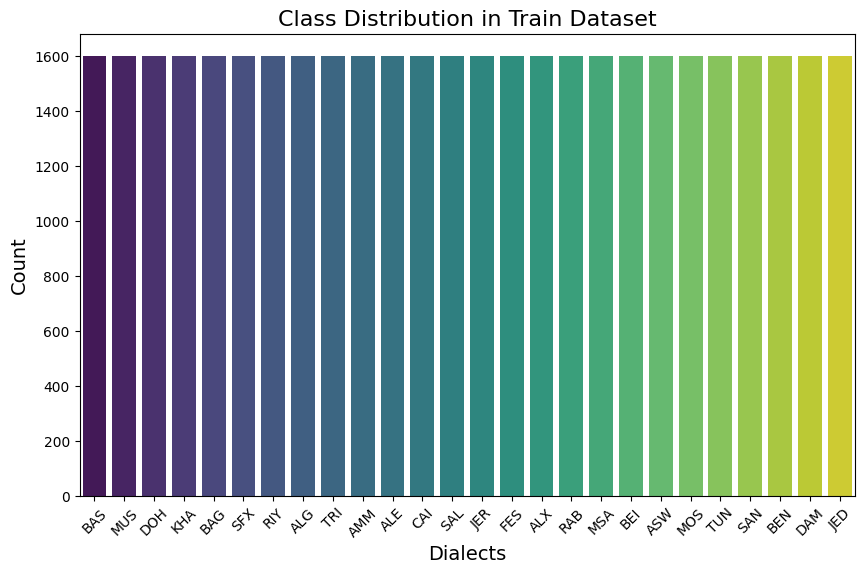

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each dialect in the train dataset
train_class_distribution = train_df['lang'].value_counts()

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=train_class_distribution.index, y=train_class_distribution.values, palette='viridis')
plt.title('Class Distribution in Train Dataset', fontsize=16)
plt.xlabel('Dialects', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.show()


<h1 style="color:red;">Text Preprocessing & Data Cleaning</h1>

In [16]:
# Ensure NLTK resources are downloaded
nltk.download('stopwords')a
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
# Define preprocessing function
def preprocess_dataframe(df):
    """
    Preprocesses a DataFrame containing columns 'lang' and 'sent'.
    Includes normalization, tokenization, and stop word removal.
    """
    # 1. Check and rename columns
    if len(df.columns) >= 2:
        df = df.iloc[:, :2]  # Select the first two columns if extra columns exist
        df.columns = ['lang', 'sent']
    else:
        raise ValueError("The DataFrame must have at least 2 columns: 'lang' and 'sent'.")

    # 2. Check for missing values
    print(f"\nMissing values before preprocessing in DataFrame:")
    print(df.isnull().sum())

    # Drop rows with missing values
    df = df.dropna()
    print(f"\nRows remaining after dropping missing values: {len(df)}")

    # 3. Strip leading and trailing whitespaces
    df['sent'] = df['sent'].str.strip()

    # 4. Text normalization: Clean and normalize the sentences
    def normalize_text(text):
        """
        Cleans and normalizes Arabic text:
        - Removes diacritics (Tashkeel).
        - Removes punctuation and special characters.
        - Converts text to lowercase.
        """
        # Remove diacritics (Tashkeel)
        text = re.sub(r'[\u064B-\u065F]', '', text)
        # Remove punctuation, numbers, and special characters
        text = re.sub(r'[^\w\s]', '', text)
        # Convert text to lowercase
        text = text.lower()
        return text

    df['sent'] = df['sent'].apply(normalize_text)

    # 5. Tokenization: Split sentences into words
    df['tokens'] = df['sent'].apply(word_tokenize)

    # 6. Remove stop words
    # Use a single unified stop word list
    arabic_stop_words = set(stopwords.words('arabic'))

    def remove_stopwords(tokens):
        """
        Removes stop words from tokenized text using a unified Arabic stop word list.
        """
        return [word for word in tokens if word not in arabic_stop_words]

    # Apply stop word removal
    df['tokens'] = df['tokens'].apply(remove_stopwords)

    # Optional: Additional column for token count (useful for analysis)
    df['token_count'] = df['tokens'].apply(len)

    return df

In [18]:
# Assuming train_df, dev_df, and test_df are already loaded
print("Preprocessing Train DataFrame:")
train_df = preprocess_dataframe(train_df)

print("\nPreprocessing Dev DataFrame:")
dev_df = preprocess_dataframe(dev_df)

print("\nPreprocessing Test DataFrame:")
test_df = preprocess_dataframe(test_df)

print("\nPreprocessed data saved to files.")

# Display summary of each dataset
print("\nTrain DataFrame Sample:")
print(train_df.head())

print("\nDev DataFrame Sample:")
print(dev_df.head())

print("\nTest DataFrame Sample:")
print(test_df.head())

Preprocessing Train DataFrame:

Missing values before preprocessing in DataFrame:
lang    0
sent    0
dtype: int64

Rows remaining after dropping missing values: 41600

Preprocessing Dev DataFrame:

Missing values before preprocessing in DataFrame:
lang    0
sent    0
dtype: int64

Rows remaining after dropping missing values: 5200

Preprocessing Test DataFrame:

Missing values before preprocessing in DataFrame:
lang    0
sent    0
dtype: int64

Rows remaining after dropping missing values: 5200

Preprocessed data saved to files.

Train DataFrame Sample:
  lang                    sent                        tokens  token_count
0  BAS          رجاءا اخذ وقتك            [رجاءا, اخذ, وقتك]            3
1  MUS           عندك واحد غير                        [عندك]            1
2  MUS         بجم هو لكل ورقة              [بجم, لكل, ورقة]            3
3  DAM  شو نوع الخبز يللي عندك  [شو, نوع, الخبز, يللي, عندك]            5
4  BEN         وين محل الهدايا           [وين, محل, الهدايا]         

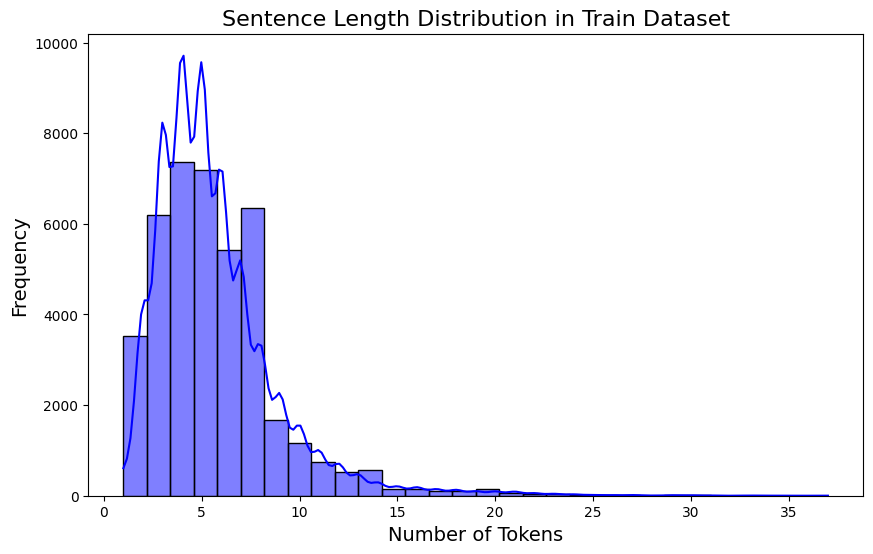

In [19]:
# Calculate sentence lengths in the train dataset
train_df['sentence_length'] = train_df['sent'].apply(lambda x: len(x.split()))

# Plot the distribution of sentence lengths
plt.figure(figsize=(10, 6))
sns.histplot(train_df['sentence_length'], bins=30, kde=True, color='blue')
plt.title('Sentence Length Distribution in Train Dataset', fontsize=16)
plt.xlabel('Number of Tokens', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()


In [20]:
print(train_df['sentence_length'].max())

37


<h1 style="color:red;">Class Selecting & Mapping</h1>

In [21]:
n_classes = 6

# Select random dialects
random.seed(962)
selected_dialects = random.sample(train_df['lang'].unique().tolist(), n_classes)
print(f"Selected Dialects (Before Mapping): {selected_dialects}")

# Filter the data to include only the selected dialects
train_df = train_df[train_df['lang'].isin(selected_dialects)]
dev_df = dev_df[dev_df['lang'].isin(selected_dialects)]
test_df = test_df[test_df['lang'].isin(selected_dialects)]

# Check missing values
print("Missing values in train_df:", train_df.isnull().sum())
print("Missing values in dev_df:", dev_df.isnull().sum())
print("Missing values in test_df:", test_df.isnull().sum())

# Encode labels into integers using LabelEncoder
label_encoder = LabelEncoder()
train_df['lang'] = label_encoder.fit_transform(train_df['lang'])
dev_df['lang'] = label_encoder.transform(dev_df['lang'])
test_df['lang'] = label_encoder.transform(test_df['lang'])

# Print the label mapping
print("Label Mapping (After Mapping):", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Convert DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df)
dev_dataset = Dataset.from_pandas(dev_df)
test_dataset = Dataset.from_pandas(test_df)

# Rename 'lang' column to 'labels' for Hugging Face Trainer compatibility
train_dataset = train_dataset.rename_column("lang", "labels")
dev_dataset = dev_dataset.rename_column("lang", "labels")
test_dataset = test_dataset.rename_column("lang", "labels")


Selected Dialects (Before Mapping): ['BEI', 'TRI', 'RIY', 'KHA', 'SAL', 'RAB']
Missing values in train_df: lang               0
sent               0
tokens             0
token_count        0
sentence_length    0
dtype: int64
Missing values in dev_df: lang           0
sent           0
tokens         0
token_count    0
dtype: int64
Missing values in test_df: lang           0
sent           0
tokens         0
token_count    0
dtype: int64
Label Mapping (After Mapping): {'BEI': 0, 'KHA': 1, 'RAB': 2, 'RIY': 3, 'SAL': 4, 'TRI': 5}


<h1 style="color:red;">Tokenization </h1>

In [23]:
max_l = 40
# Tokenize the Data
tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv02")

def tokenize_function(examples):
    return tokenizer(examples["sent"], truncation=True, padding="max_length", max_length=max_l)

train_dataset = train_dataset.map(tokenize_function, batched=True, desc="Tokenizing train dataset")
dev_dataset = dev_dataset.map(tokenize_function, batched=True, desc="Tokenizing dev dataset")
test_dataset = test_dataset.map(tokenize_function, batched=True, desc="Tokenizing test dataset")

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
dev_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Step 3: Load the Model
model = AutoModelForSequenceClassification.from_pretrained(
    "aubmindlab/bert-base-arabertv02",
    num_labels=len(label_encoder.classes_)
)

Tokenizing test dataset: 100%|██████████| 1200/1200 [00:00<00:00, 16910.87 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<h1 style="color:red;">Model Training</h1>

In [24]:
# Define Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,  # Smaller batch size
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
    fp16=True,  # Enable mixed precision
)

In [25]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
)

In [6]:
# Train the Model
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.678900,0.641101
2,0.470600,0.604876
3,0.434900,0.566066


TrainOutput(global_step=3600, training_loss=0.6359348470634885, metrics={'train_runtime': 9456.8516, 'train_samples_per_second': 3.045, 'train_steps_per_second': 0.381, 'total_flos': 1894467634790400.0, 'train_loss': 0.6359348470634885, 'epoch': 3.0})

<h1 style="color:red;">Model Evaluation</h1>

In [7]:

# Step 7: Evaluate the Model
test_results = trainer.evaluate(test_dataset)
print("Test Results:", test_results)

# Detailed Classification Report
from sklearn.metrics import classification_report
test_predictions = trainer.predict(test_dataset)
predicted_labels = test_predictions.predictions.argmax(axis=1)
true_labels = test_dataset["labels"]
print(classification_report(true_labels, predicted_labels, target_names=label_encoder.classes_))

Test Results: {'eval_loss': 0.6002330780029297, 'eval_runtime': 87.3997, 'eval_samples_per_second': 13.73, 'eval_steps_per_second': 0.858, 'epoch': 3.0}
              precision    recall  f1-score   support

         BEI       0.91      0.73      0.81       200
         KHA       0.77      0.80      0.78       200
         RAB       0.94      0.92      0.93       200
         RIY       0.63      0.84      0.72       200
         SAL       0.76      0.67      0.71       200
         TRI       0.88      0.84      0.86       200

    accuracy                           0.80      1200
   macro avg       0.81      0.80      0.80      1200
weighted avg       0.81      0.80      0.80      1200



<Figure size 1000x800 with 0 Axes>

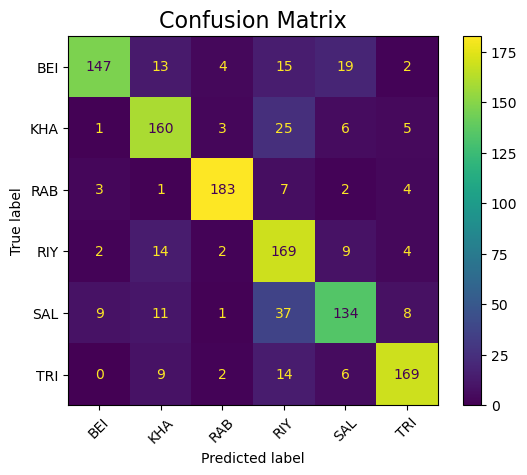

In [9]:
# Generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
plt.figure(figsize=(10, 8))
disp.plot(cmap='viridis', xticks_rotation=45)
plt.title('Confusion Matrix', fontsize=16)
plt.show()


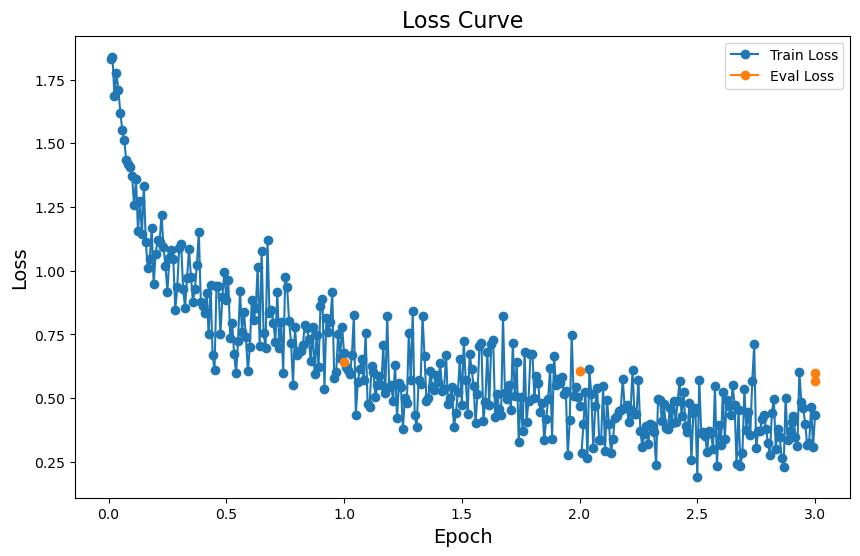

In [12]:
# Extract training logs from the Trainer
training_logs = trainer6.state.log_history

# Convert logs to a DataFrame for easier visualization
logs_df = pd.DataFrame(training_logs)

# Plot loss curve
plt.figure(figsize=(10, 6))
plt.plot(logs_df['epoch'], logs_df['loss'], label='Train Loss', marker='o')
if 'eval_loss' in logs_df.columns:
    plt.plot(logs_df['epoch'], logs_df['eval_loss'], label='Eval Loss', marker='o')
plt.title('Loss Curve', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()
plt.show()



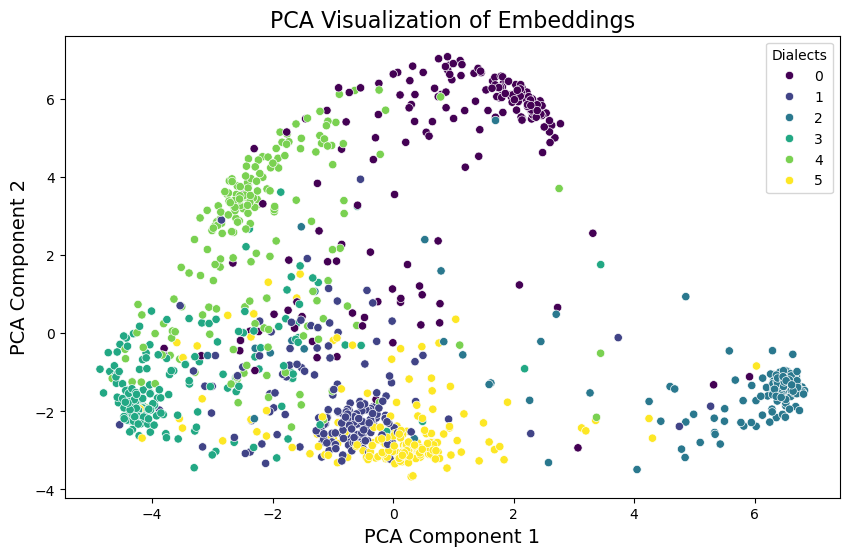

In [13]:
# Extract embeddings from the test dataset (example: logits)
embeddings = test_predictions.predictions

# Reduce dimensionality to 2D using PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Plot the embeddings
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=reduced_embeddings[:, 0], y=reduced_embeddings[:, 1], 
    hue=true_labels, palette='viridis', legend='full'
)
plt.title('PCA Visualization of Embeddings', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=14)
plt.ylabel('PCA Component 2', fontsize=14)
plt.legend(title='Dialects', loc='upper right')
plt.show()


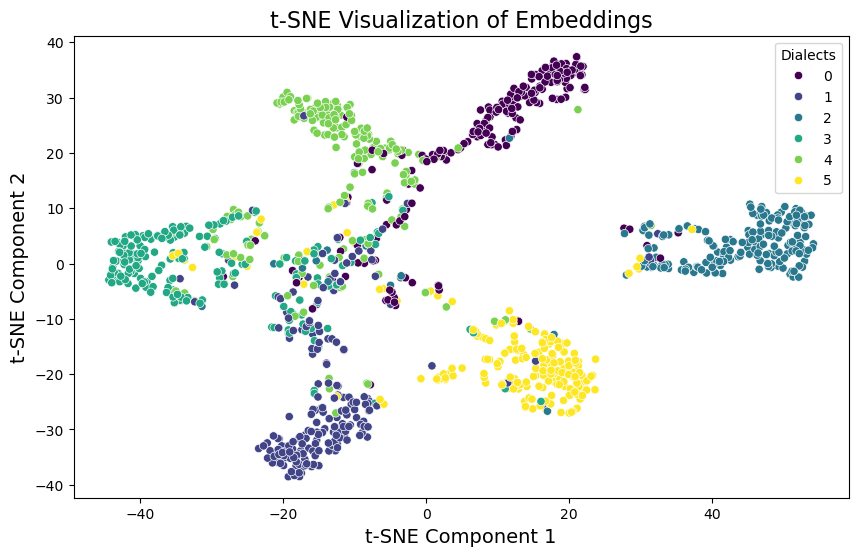

In [14]:
# Reduce dimensionality to 2D using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced_embeddings_tsne = tsne.fit_transform(embeddings)

# Plot the embeddings
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=reduced_embeddings_tsne[:, 0], y=reduced_embeddings_tsne[:, 1],
    hue=true_labels, palette='viridis', legend='full'
)
plt.title('t-SNE Visualization of Embeddings', fontsize=16)
plt.xlabel('t-SNE Component 1', fontsize=14)
plt.ylabel('t-SNE Component 2', fontsize=14)
plt.legend(title='Dialects', loc='upper right')
plt.show()
